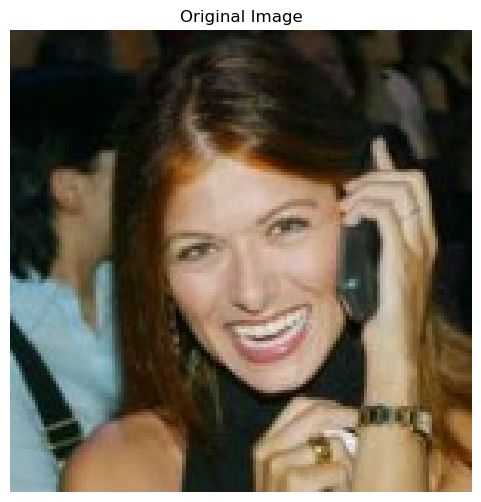

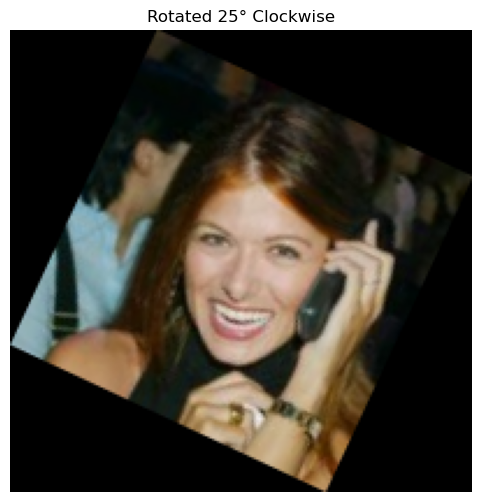

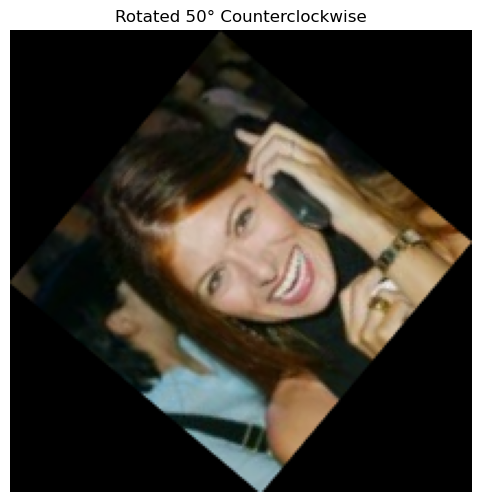

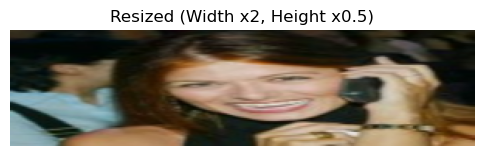

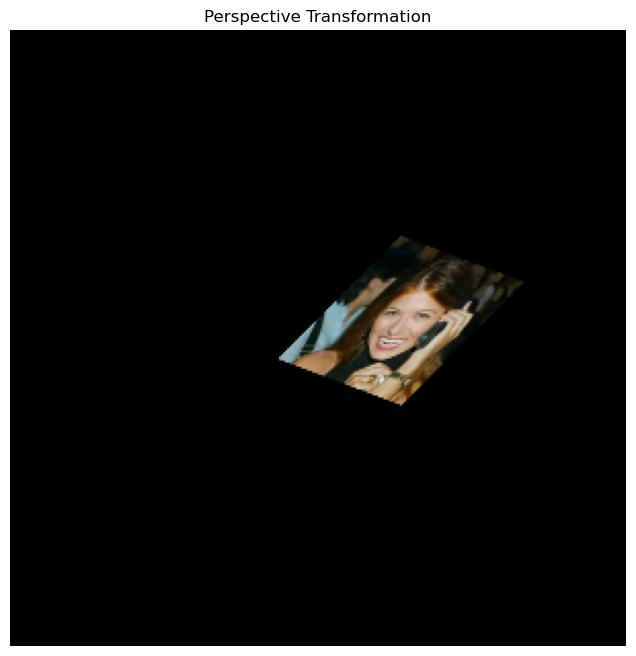

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load image
image_path = 'Assignment5_Files/faces/Debra_Messing_0001.jpg'
image = cv.imread(image_path)
if image is None:
    raise FileNotFoundError("Image not found at the specified path.")

# Display original image
plt.figure(figsize=(6,6))
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')
plt.show()

# Function to rotate image without cropping
def rotate_image_keep_bounds(img, angle):
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv.getRotationMatrix2D(center, angle, 1.0)

    # Compute new bounding dimensions
    cos = np.abs(M[0, 0])
    sin = np.abs(M[0, 1])
    new_w = int((h * sin) + (w * cos))
    new_h = int((h * cos) + (w * sin))

    # Adjust rotation matrix to account for translation
    M[0, 2] += (new_w / 2) - center[0]
    M[1, 2] += (new_h / 2) - center[1]

    rotated = cv.warpAffine(img, M, (new_w, new_h))
    return rotated

# Function to resize image
def resize_image(img, fx, fy):
    resized = cv.resize(img, None, fx=fx, fy=fy, interpolation=cv.INTER_LINEAR)
    return resized

# Function for perspective transformation
def perspective_transform(img, H):
    (h, w) = img.shape[:2]
    transformed = cv.warpPerspective(img, H, (w*2, h*2))  # Enlarged canvas
    return transformed

# Homography matrix
H = np.array([[0.4, -0.4, 190],
              [0.15, 0.4, 100],
              [0, 0, 1]], dtype=np.float32)

# --- Show requested transformations ---

# 1. Rotation: 25 degrees clockwise
rotated_25 = rotate_image_keep_bounds(image, -25)
plt.figure(figsize=(6,6))
plt.imshow(cv.cvtColor(rotated_25, cv.COLOR_BGR2RGB))
plt.title("Rotated 25° Clockwise")
plt.axis('off')
plt.show()

# 2. Rotation: 50 degrees counterclockwise
rotated_50 = rotate_image_keep_bounds(image, 50)
plt.figure(figsize=(6,6))
plt.imshow(cv.cvtColor(rotated_50, cv.COLOR_BGR2RGB))
plt.title("Rotated 50° Counterclockwise")
plt.axis('off')
plt.show()

# 3. Resize: double width, half height
resized_img = resize_image(image, fx=2, fy=0.5)
plt.figure(figsize=(6,6))
plt.imshow(cv.cvtColor(resized_img, cv.COLOR_BGR2RGB))
plt.title("Resized (Width x2, Height x0.5)")
plt.axis('off')
plt.show()

# 4. Perspective Transformation
perspective_img = perspective_transform(image, H)
plt.figure(figsize=(8,8))
plt.imshow(cv.cvtColor(perspective_img, cv.COLOR_BGR2RGB))
plt.title("Perspective Transformation")
plt.axis('off')
plt.show()

Choose operation: rotate / resize / perspective / exit:  rotate
Enter rotation angle (positive = counterclockwise, negative = clockwise):  -25


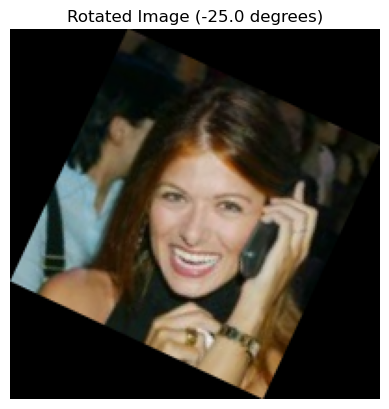

Choose operation: rotate / resize / perspective / exit:  rotate
Enter rotation angle (positive = counterclockwise, negative = clockwise):  50


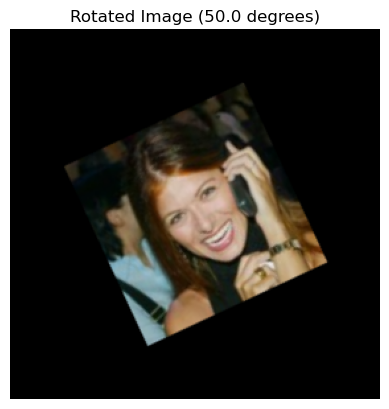

Choose operation: rotate / resize / perspective / exit:  resize
Enter width scaling factor (e.g., 2 for double width):  2
Enter height scaling factor (e.g., 0.5 for half height):  0.5


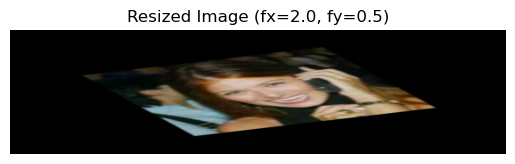

Choose operation: rotate / resize / perspective / exit:  perspective


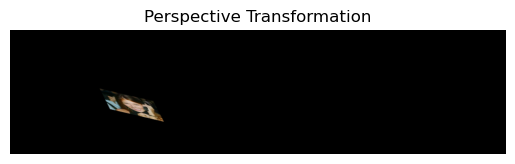

Choose operation: rotate / resize / perspective / exit:  exit


Exiting...


In [6]:
# Interactive loop
while True:
    choice = input("Choose operation: rotate / resize / perspective / exit: ").strip().lower()
    
    if choice == 'rotate':
        angle = float(input("Enter rotation angle (positive = counterclockwise, negative = clockwise): "))
        rotated_img = rotate_image_keep_bounds(image, angle)
        plt.imshow(cv.cvtColor(rotated_img, cv.COLOR_BGR2RGB))
        plt.title(f"Rotated Image ({angle} degrees)")
        plt.axis('off')
        plt.show()
        image=rotated_img  #keep working on it
    
    elif choice == 'resize':
        fx = float(input("Enter width scaling factor (e.g., 2 for double width): "))
        fy = float(input("Enter height scaling factor (e.g., 0.5 for half height): "))
        resized_img = resize_image(image, fx, fy)
        plt.imshow(cv.cvtColor(resized_img, cv.COLOR_BGR2RGB))
        plt.title(f"Resized Image (fx={fx}, fy={fy})")
        plt.axis('off')
        plt.show()
        image=resized_img #keep working on it
    
    elif choice == 'perspective':
        transformed_img = perspective_transform(image, H)
        plt.imshow(cv.cvtColor(transformed_img, cv.COLOR_BGR2RGB))
        plt.title("Perspective Transformation")
        plt.axis('off')
        plt.show()
        image=transformed_img #keep working on it
    
    elif choice == 'exit':
        print("Exiting...")
        break
    
    else:
        print("Invalid choice. Please try again.")